# Введение #

В первых двух уроках мы научились строить полносвязные сети из слоев плотных (Dense) слоев. При первом создании все веса сети устанавливаются случайным образом — сеть еще ничего не "знает". В этом уроке мы увидим, как обучать нейронную сеть; мы увидим, как нейронные сети *учатся*.

Как и в любой задаче машинного обучения, мы начинаем с набора тренировочных данных. Каждый пример в тренировочных данных состоит из некоторых признаков (входные данные) вместе с ожидаемой целевой переменной (выходные данные). Обучение сети означает настройку ее весов таким образом, чтобы она могла преобразовывать признаки в целевую переменную. В наборе данных *80 Cereals*, например, мы хотим, чтобы сеть могла взять содержание `'sugar'`, `'fiber'` и `'protein'` каждой каши и выдать прогноз для ее калорийности `'calories'`. Если мы сможем успешно обучить сеть делать это, ее веса должны каким-то образом представлять взаимосвязь между этими признаками и целевой переменной, выраженную в тренировочных данных.

В дополнение к тренировочным данным нам нужны еще две вещи:
- "Функция потерь", которая измеряет, насколько хороши прогнозы сети.
- "Оптимизатор", который может указать сети, как изменять ее веса.

# Функция потерь #

Мы видели, как спроектировать архитектуру сети, но мы еще не видели, как указать сети, *какую* проблему решать. Это задача функции потерь.

**Функция потерь** измеряет расхождение между истинным значением целевой переменной и значением, которое предсказывает модель.

Для разных задач требуются разные функции потерь. Мы рассматривали **задачи регрессии**, где задача состоит в том, чтобы предсказать некоторое числовое значение — калории в *80 Cereals*, рейтинг в *Red Wine Quality*. Другие задачи регрессии могут включать прогнозирование цены дома или топливной эффективности автомобиля.

Общей функцией потерь для задач регрессии является **средняя абсолютная ошибка** или **MAE**. Для каждого прогноза `y_pred` MAE измеряет расхождение с истинной целевой переменной `y_true` через абсолютную разность `abs(y_true - y_pred)`.

Общая потеря MAE на наборе данных — это среднее всех этих абсолютных разностей.

<figure style="padding: 1em;">
<img src="https://storage.googleapis.com/kaggle-media/learn/images/VDcvkZN.png" width="500" alt="График, показывающий отрезки ошибок от точек данных до подобранной линии.">
<figcaption style="textalign: center; font-style: italic"><center>Средняя абсолютная ошибка — это средняя длина между подобранной кривой и точками данных.
</center></figcaption>
</figure>

Помимо MAE, другими функциями потерь, которые вы можете встретить для задач регрессии, являются среднеквадратичная ошибка (MSE) или потеря Хубера (обе доступны в Keras).

Во время обучения модель будет использовать функцию потерь в качестве ориентира для поиска правильных значений своих весов (меньшая потеря лучше). Другими словами, функция потерь сообщает сети ее цель.

# Оптимизатор - Стохастический градиентный спуск #

Мы описали проблему, которую сеть должна решить, но теперь нам нужно сказать, *как* ее решать. Это задача **оптимизатора**. Оптимизатор — это алгоритм, который настраивает веса для минимизации потерь.

Практически все алгоритмы оптимизации, используемые в глубоком обучении, принадлежат к семейству, называемому **стохастический градиентный спуск**. Это итеративные алгоритмы, которые обучают сеть пошагово. Один **шаг** обучения выглядит так:
1. Выборка некоторой части тренировочных данных и их пропуск через сеть для получения прогнозов.
2. Измерение потерь между прогнозами и истинными значениями.
3. Наконец, корректировка весов в направлении, которое уменьшает потери.

Затем просто повторяйте это снова и снова, пока потери не станут настолько малыми, насколько вы хотите (или пока они не перестанут уменьшаться).

<figure style="padding: 1em;">
<img src="https://storage.googleapis.com/kaggle-media/learn/images/rFI1tIk.gif" width="1600" alt="Подгонка линии пакет за пакетом. Потери уменьшаются, а веса приближаются к своим истинным значениям.">
<figcaption style="textalign: center; font-style: italic"><center>Обучение нейронной сети с помощью стохастического градиентного спуска.
</center></figcaption>
</figure>

Выборка тренировочных данных на каждой итерации называется **мини-пакетом** (или часто просто "пакетом"), а полный проход по тренировочным данным называется **эпохой**. Количество эпох, на которое вы обучаете, определяет, сколько раз сеть увидит каждый тренировочный пример.

Анимация показывает линейную модель из Урока 1, обучаемую с помощью SGD. Бледно-красные точки изображают весь тренировочный набор, а ярко-красные точки — это мини-пакеты. Каждый раз, когда SGD видит новый мини-пакет, он сдвигает веса (`w` — наклон и `b` — пересечение с осью y) в сторону их правильных значений для этого пакета. Пакет за пакетом линия в конечном итоге сходится к своей наилучшей подгонке. Вы можете видеть, что потери уменьшаются по мере того, как веса приближаются к своим истинным значениям.

## Скорость обучения и размер пакета ##

Обратите внимание, что линия сдвигается лишь немного в направлении каждого пакета (вместо того, чтобы перемещаться полностью). Размер этих сдвигов определяется **скоростью обучения**. Меньшая скорость обучения означает, что сети нужно увидеть больше мини-пакетов, прежде чем ее веса сойдутся к своим наилучшим значениям.

Скорость обучения и размер мини-пакетов — это два параметра, которые оказывают наибольшее влияние на процесс обучения SGD. Их взаимодействие часто бывает тонким, и правильный выбор этих параметров не всегда очевиден. (Мы исследуем эти эффекты в упражнении.)

К счастью, для большинства работ не потребуется обширный поиск гиперпараметров для получения удовлетворительных результатов. **Adam** — это алгоритм SGD, который имеет адаптивную скорость обучения, что делает его подходящим для большинства задач без какой-либо настройки параметров (он является "самонастраивающимся", в некотором смысле). Adam — отличный оптимизатор общего назначения.

## Добавление функции потерь и оптимизатора ##

После определения модели вы можете добавить функцию потерь и оптимизатор с помощью метода `compile` модели:

```
model.compile(
    optimizer="adam",
    loss="mae",
)
```

Обратите внимание, что мы можем указать функцию потерь и оптимизатор просто строкой. Вы также можете получить доступ к ним напрямую через API Keras — если вы хотите настроить параметры, например, — но для нас значения по умолчанию будут работать нормально.

<blockquote style="margin-right:auto; margin-left:auto; background-color: #ebf9ff; padding: 1em; margin:24px;">
    <strong>Что в имени?</strong><br>
**Градиент** — это вектор, который говорит нам, в каком направлении должны двигаться веса. Точнее, он говорит нам, как изменить веса, чтобы изменить потери <em>быстрее всего</em>. Мы называем наш процесс градиентным <strong>спуском</strong>, потому что он использует градиент, чтобы <em>спускаться</em> по кривой потерь к минимуму. <strong>Стохастический</strong> означает "определяемый случайностью". Наше обучение является <em>стохастическим</em>, потому что мини-пакеты являются <em>случайными выборками</em> из набора данных. И вот почему это называется SGD!
</blockquote>

# Пример - Качество красного вина #

Теперь мы знаем все, что нужно, чтобы начать обучение моделей глубокого обучения. Итак, давайте посмотрим на это в действии! Мы будем использовать набор данных *Red Wine Quality*.

Этот набор данных состоит из физико-химических измерений около 1600 португальских красных вин. Также включена оценка качества для каждого вина по результатам дегустации вслепую. Насколько хорошо мы можем предсказать воспринимаемое качество вина по этим измерениям?

Мы поместили всю подготовку данных в следующую скрытую ячейку. Это не важно для того, что будет дальше, так что можете пропустить ее. Одна вещь, которую вы могли бы заметить, это то, что мы масштабировали каждый признак так, чтобы он лежал в интервале $[0, 1]$. Как мы обсудим подробнее в Уроке 5, нейронные сети обычно работают лучше всего, когда их входные данные находятся в общем масштабе.

In [16]:

import pandas as pd
from IPython.display import display

red_wine = pd.read_csv('./data/red-wine.csv')

# Создание тренировочной и валидационной выборок
df_train = red_wine.sample(frac=0.7, random_state=0)
df_valid = red_wine.drop(df_train.index)
display(df_train.head(4))

# Масштабирование к [0, 1]
max_ = df_train.max(axis=0)
min_ = df_train.min(axis=0)
df_train = (df_train - min_) / (max_ - min_)
df_valid = (df_valid - min_) / (max_ - min_)

# Разделение на признаки и целевую переменную
X_train = df_train.drop('quality', axis=1)
X_valid = df_valid.drop('quality', axis=1)
y_train = df_train['quality']
y_valid = df_valid['quality']

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
1109,10.8,0.470,0.43,2.10,0.171,27.0,66.0,0.99820,3.17,0.76,10.8,6
1032,8.1,0.820,0.00,4.10,0.095,5.0,14.0,0.99854,3.36,0.53,9.6,5
1002,9.1,0.290,0.33,2.05,0.063,13.0,27.0,0.99516,3.26,0.84,11.7,7
487,10.2,0.645,0.36,1.80,0.053,5.0,14.0,0.99820,3.17,0.42,10.0,6


Сколько входов должна иметь эта сеть? Мы можем узнать это, посмотрев на количество столбцов в матрице данных. Убедитесь, что вы не включаете целевую переменную (`'quality'`) сюда — только входные признаки.

In [17]:
print(X_train.shape) # вывод формы тренировочных признаков


(1119, 11)


Одиннадцать столбцов означают одиннадцать входов.

Мы выбрали трехуровневую сеть с более чем 1500 нейронов. Эта сеть должна быть способна изучать довольно сложные взаимосвязи в данных.

In [18]:
from tensorflow import keras
from tensorflow.keras import layers

model = keras.Sequential([
    layers.Dense(512, activation='relu', input_shape=[11]),
    layers.Dense(512, activation='relu'),
    layers.Dense(512, activation='relu'),
    layers.Dense(1),
])

c:\Users\iOlvik\Documents\1_Dev\Work\ML_training\venv\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Определение архитектуры вашей модели должно быть частью процесса. Начните с простого и используйте валидационную потерю в качестве ориентира. Вы узнаете больше о разработке моделей в упражнениях.

После определения модели мы компилируем ее с оптимизатором и функцией потерь.

In [19]:
model.compile(
    optimizer='adam',
    loss='mae',
)

Теперь мы готовы начать обучение! Мы указали Keras подавать оптимизатору по 256 строк тренировочных данных за раз (параметр `batch_size`) и делать это 10 раз, проходя через весь набор данных (параметр `epochs`).

In [20]:
history = model.fit(
    X_train, y_train,
    validation_data=(X_valid, y_valid),
    batch_size=256,
    epochs=10,
)

Epoch 1/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - loss: 0.2783 - val_loss: 0.1350
Epoch 2/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.1537 - val_loss: 0.1289
Epoch 3/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.1351 - val_loss: 0.1254
Epoch 4/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.1208 - val_loss: 0.1235
Epoch 5/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.1121 - val_loss: 0.1087
Epoch 6/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.1113 - val_loss: 0.1097
Epoch 7/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.1073 - val_loss: 0.1021
Epoch 8/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.1045 - val_loss: 0.1049
Epoch 9/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.1033 - val_loss: 0.1013
Epoch 10/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.1011 - val_loss: 0.1052


Вы можете видеть, что Keras будет обновлять информацию о потерях по мере обучения модели.

Часто лучший способ визуализировать потери — это построить график. Метод `fit` на самом деле сохраняет запись потерь, полученных во время обучения, в объекте `History`. Мы преобразуем данные в Pandas DataFrame, что упростит построение графика.

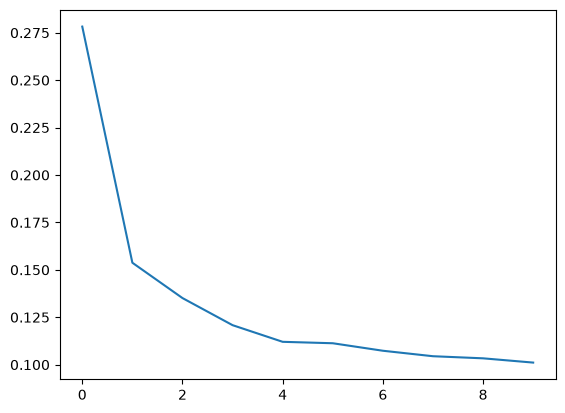

In [21]:
import pandas as pd

# преобразование истории обучения в dataframe
history_df = pd.DataFrame(history.history)
# использование встроенного метода построения графиков Pandas
history_df['loss'].plot();

Обратите внимание, как потери выходят на плато по мере прохождения эпох. Когда кривая потерь становится горизонтальной, это означает, что модель изучила все, что могла, и нет причин продолжать обучение на дополнительных эпохах.

# Ваша очередь #

Теперь [**используйте стохастический градиентный спуск**](https://www.kaggle.com/kernels/fork/11887330) для обучения вашей сети.

---




*Есть вопросы или комментарии? Посетите [форум для обсуждения курса](https://www.kaggle.com/learn/intro-to-deep-learning/discussion), чтобы пообщаться с другими учениками.*